In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../data/raw/Sample - Superstore.csv', encoding='cp1252')
df.head(5)

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11/8/2016,11/11/2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,6/12/2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10/11/2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


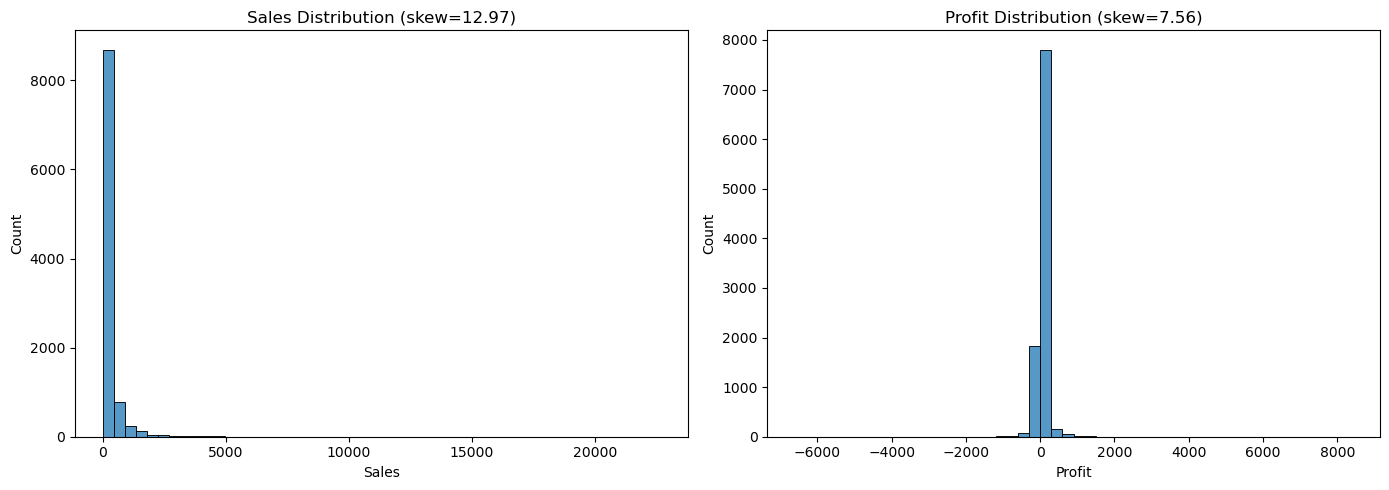

In [4]:
# 1. Sales & Profit distribution (visual confirmation of skewness)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df['Sales'], bins=50, ax=axes[0])
axes[0].set_title(f"Sales Distribution (skew={df['Sales'].skew():.2f})")
sns.histplot(df['Profit'], bins=50, ax=axes[1])
axes[1].set_title(f"Profit Distribution (skew={df['Profit'].skew():.2f})")
plt.tight_layout()
plt.savefig('../docs/images/sales_profit_distribution.png', dpi=150)
plt.show()


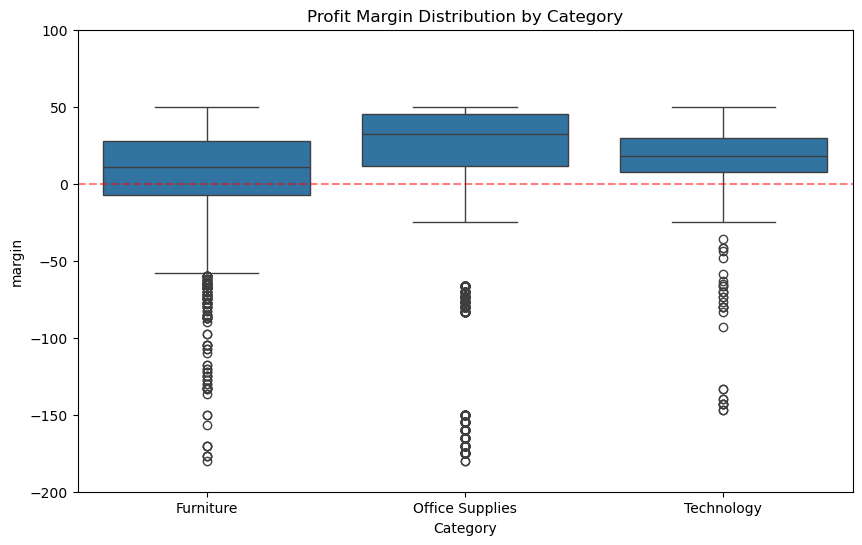

In [5]:
# 2. Profit margin by Category (boxplot) — visualizes the BCG/margin 
#    mismatch findings (Finding 16)

df['margin'] = df['Profit'] / df['Sales'] * 100
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Category', y='margin')
plt.axhline(0, color='red', linestyle='--', alpha=0.5)
plt.title('Profit Margin Distribution by Category')
plt.ylim(-200, 100)  # clip extreme outliers for readability
plt.savefig('../docs/images/margin_by_category.png', dpi=150)
plt.show()

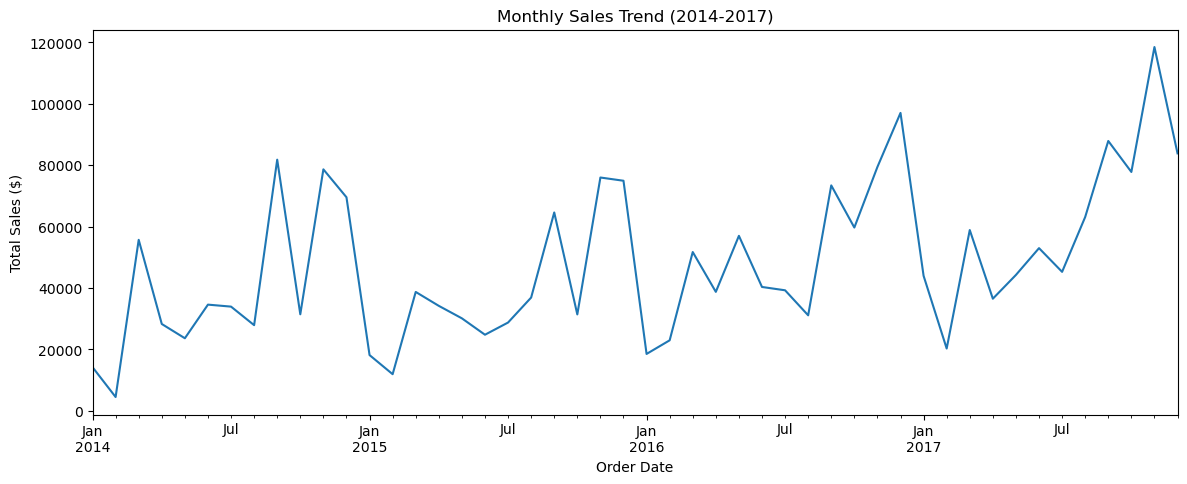

In [6]:
# ============================================
# 3. Monthly sales trend (visualizes Finding 2 & 12: seasonality)
# ============================================
df['Order Date'] = pd.to_datetime(df['Order Date'], format='%m/%d/%Y')
monthly = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum()
plt.figure(figsize=(14, 5))
monthly.plot()
plt.title('Monthly Sales Trend (2014-2017)')
plt.ylabel('Total Sales ($)')
plt.savefig('../docs/images/monthly_sales_trend.png', dpi=150)
plt.show()

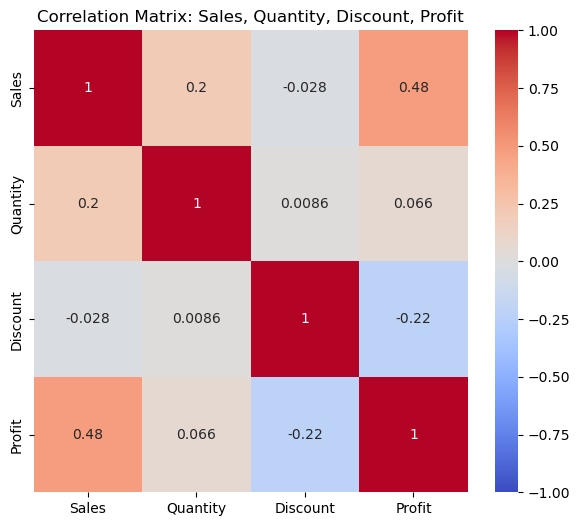

          Sales  Quantity  Discount  Profit
Sales     1.000     0.201    -0.028   0.479
Quantity  0.201     1.000     0.009   0.066
Discount -0.028     0.009     1.000  -0.219
Profit    0.479     0.066    -0.219   1.000


In [7]:
# 4. Multivariate correlation matrix
corr_vars = df[['Sales', 'Quantity', 'Discount', 'Profit']]
corr_matrix = corr_vars.corr()

plt.figure(figsize=(7, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlation Matrix: Sales, Quantity, Discount, Profit')
plt.savefig('../docs/images/correlation_matrix.png', dpi=150)
plt.show()

print(corr_matrix.round(3))

In [8]:
# Are margin values clustering at discrete levels (suggesting a 
# formulaic profit generation, not organic transaction data)?
print(df['margin'].round(0).value_counts().head(15))

margin
48.0    509
35.0    443
26.0    364
34.0    360
47.0    353
36.0    338
49.0    315
29.0    303
28.0    288
46.0    267
32.0    262
8.0     240
11.0    240
10.0    239
27.0    236
Name: count, dtype: int64


In [10]:
# Test: is margin nearly CONSTANT within each (Category, Discount) 
# combination? If std is near-zero, this confirms formulaic generation.
grouped = df.groupby(['Category', 'Discount'])['margin'].agg(['mean', 'std', 'count'])
grouped = grouped[grouped['count'] >= 5]  # ignore tiny/noisy groups
print(grouped.sort_values('count', ascending=False).head(20))

                                mean        std  count
Category        Discount                              
Office Supplies 0.00       36.711090  13.812834   3129
                0.20       23.158791  17.072095   2201
Technology      0.20       11.052319  13.953977    841
Furniture       0.00       29.001196  10.655689    836
Technology      0.00       28.925570  11.673616    833
Furniture       0.20        7.158537  12.996855    615
Office Supplies 0.70      -74.508772   5.229271    380
                0.80     -182.500000  40.040740    300
Furniture       0.30      -12.065637  10.087278    222
                0.60      -68.913043  28.900087    138
Technology      0.40      -15.419847  16.148805    131
Furniture       0.10       13.157895   7.406043     76
                0.40      -34.177778   9.963798     75
                0.50      -62.592593  10.098605     54
                0.15        3.416290   7.898053     52
                0.32      -17.429194  10.038054     27
Technology

In [17]:
# Step 1: Check basket size distribution before choosing a method
basket_size = df.groupby('Order ID')['Product ID'].nunique()
print(basket_size.describe())
print("\nOrders with only 1 distinct product:", (basket_size == 1).sum(), 
      f"({(basket_size == 1).mean()*100:.1f}%)")
print("Orders with 2+ distinct products:", (basket_size >= 2).sum(),
      f"({(basket_size >= 2).mean()*100:.1f}%)")

count    5009.000000
mean        1.993611
std         1.408823
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        14.000000
Name: Product ID, dtype: float64

Orders with only 1 distinct product: 2540 (50.7%)
Orders with 2+ distinct products: 2469 (49.3%)


In [19]:
# Verify basket size at Sub-Category granularity before running Apriori
subcat_basket_size = df.groupby('Order ID')['Sub-Category'].nunique()
print(subcat_basket_size.describe())
print("Orders with 2+ distinct sub-categories:", 
      (subcat_basket_size >= 2).sum(),
      f"({(subcat_basket_size >= 2).mean()*100:.1f}%)")

count    5009.000000
mean        1.828509
std         1.154731
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        10.000000
Name: Sub-Category, dtype: float64
Orders with 2+ distinct sub-categories: 2346 (46.8%)


In [25]:
from mlxtend.frequent_patterns import apriori, association_rules
from mlxtend.preprocessing import TransactionEncoder

subcat_transactions = df.groupby('Order ID')['Sub-Category'].apply(lambda x: list(set(x))).tolist()
te = TransactionEncoder()
te_ary = te.fit(subcat_transactions).transform(subcat_transactions)
subcat_df = pd.DataFrame(te_ary, columns=te.columns_)

frequent_subcat = apriori(subcat_df, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_subcat, metric="lift", min_threshold=1.1)
rules_sorted = rules.sort_values('lift', ascending=False)
print(rules_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

Empty DataFrame
Columns: [antecedents, consequents, support, confidence, lift]
Index: []


In [27]:
# Diagnostic: how many itemsets did apriori actually find, and at what size?
print("Total frequent itemsets found:", len(frequent_subcat))
frequent_subcat['length'] = frequent_subcat['itemsets'].apply(len)
print(frequent_subcat['length'].value_counts())
print("\nTop 10 by support:")
print(frequent_subcat.sort_values('support', ascending=False).head(10))

Total frequent itemsets found: 38
length
2    22
1    16
Name: count, dtype: int64

Top 10 by support:
     support       itemsets  length
3   0.262727      (Binders)       1
11  0.237772        (Paper)       1
8   0.175085  (Furnishings)       1
12  0.162507       (Phones)       1
13  0.155121      (Storage)       1
2   0.145937          (Art)       1
0   0.143342  (Accessories)       1
5   0.114993       (Chairs)       1
1   0.090038   (Appliances)       1
9   0.069076       (Labels)       1


In [29]:
# Show ALL length-2 rules with their actual lift, unfiltered
rules_all = association_rules(frequent_subcat, metric="lift", min_threshold=0)
rules_all_sorted = rules_all.sort_values('lift', ascending=False)
print(rules_all_sorted[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(15))

print(f"\nTotal rules generated: {len(rules_all)}")
print(f"Rules with lift > 1.0 (positive association): {(rules_all['lift'] > 1.0).sum()}")
print(f"Rules with lift < 1.0 (negative association): {(rules_all['lift'] < 1.0).sum()}")

      antecedents    consequents   support  confidence      lift
11      (Binders)   (Appliances)  0.025953    0.098784  1.097140
10   (Appliances)      (Binders)  0.025953    0.288248  1.097140
18       (Phones)          (Art)  0.024755    0.152334  1.043833
19          (Art)       (Phones)  0.024755    0.169631  1.043833
35  (Furnishings)       (Phones)  0.029547    0.168757  1.038458
34       (Phones)  (Furnishings)  0.029547    0.181818  1.038458
12        (Paper)   (Appliances)  0.021761    0.091520  1.016458
13   (Appliances)        (Paper)  0.021761    0.241685  1.016458
36  (Furnishings)      (Storage)  0.027550    0.157355  1.014401
37      (Storage)  (Furnishings)  0.027550    0.177606  1.014401
6        (Phones)  (Accessories)  0.023158    0.142506  0.994169
7   (Accessories)       (Phones)  0.023158    0.161560  0.994169
29      (Storage)      (Binders)  0.039728    0.256113  0.974826
28      (Binders)      (Storage)  0.039728    0.151216  0.974826
30        (Paper)       (